# CNNs & Resnets

In this section I'll review my neural networks knowledge, it has been a while since I programmed one of those. Will start by making very simply neural network and will assemble a Resnet34 in the end.

## The Basics of NNs

The objectives are to learn how to create my own torch module.

In [58]:
import sys
import math
from pathlib import Path
sys.path.insert(0, './arena_helpers')
sys.path.insert(0, '..')
print(Path.cwd())

import json
from collections import namedtuple
from dataclasses import dataclass
from pathlib import Path

import einops
import numpy as np
import torch as t
import torch.nn as nn
import torch.nn.functional as F
import torchinfo
from IPython.display import display
from jaxtyping import Float, Int
from PIL import Image
from rich import print as rprint
from rich.table import Table
from torch import Tensor
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms
from tqdm.notebook import tqdm
from plotly_utils import line
import arena_helpers.tests as tests
import arena_helpers.utils as utils

/home/youssef/projects/AI-safety/arena-3.0/prereqs/cnn-resnets


Don't forget to make a `device` global variable

In [5]:
device = t.device("cuda" if t.cuda.is_available() else "cpu")
device

device(type='cuda')

### Implementing ReLU

let's now fill the `forward` method of the `ReLU` class.

In [6]:
class ReLU(nn.Module):
    def forward(self, x: Tensor) -> Tensor:
        y = t.maximum(t.zeros((1),device=x.device),x) #make use of broadcasting
        return y


tests.test_relu(ReLU)

All tests in `test_relu` passed!


### Implementing Linear

we'll implement a `Linear` module, that does a linear transformation.

In [7]:
t.distributions.Uniform(2, 10).sample((5,))

tensor([5.5365, 5.9238, 3.6639, 7.8237, 5.2865])

In [8]:
class Linear(nn.Module):
    def __init__(self, in_features: int, out_features: int, bias=True):
        """
        A simple linear (technically, affine) transformation.

        The fields should be named `weight` and `bias` for compatibility with PyTorch.
        If `bias` is False, set `self.bias` to None.
        """
        super().__init__()
        # let's initialize weights
        self.bound = 1/ math.sqrt(in_features)
        self.is_bias = bias
        self.in_features = in_features
        self.out_features = out_features

        self.weight = nn.Parameter(t.distributions.Uniform(-self.bound, self.bound).sample((out_features, in_features)))
        if self.is_bias:
            self.bias = nn.Parameter(t.zeros(out_features))
        else:
            self.bias = None
    def forward(self, x: Tensor) -> Tensor:
        """
        x: shape (*, in_features)
        Return: shape (*, out_features)
        """
        y = x @ self.weight.T
        if self.is_bias:
            y += self.bias

        return y

    def extra_repr(self) -> str:
        return f"in_features={self.in_features}, out_features={self.out_features}, is_biased={self.is_bias}"


tests.test_linear_parameters(Linear, bias=False)
tests.test_linear_parameters(Linear, bias=True)
tests.test_linear_forward(Linear, bias=False)
tests.test_linear_forward(Linear, bias=True)

All tests in `test_linear_parameters` passed!
All tests in `test_linear_parameters` passed!
All tests in `test_linear_forward` passed!
All tests in `test_linear_forward` passed!


### Flatten

In [9]:
class Flatten(nn.Module):
    def __init__(self, start_dim: int = 1, end_dim: int = -1) -> None:
        super().__init__()
        self.start_dim = start_dim
        self.end_dim = end_dim

    def forward(self, input: Tensor) -> Tensor:
        """
        Flatten out dimensions from start_dim to end_dim, inclusive of both.
        """
        shape = input.shape

        # Get start & end dims, handling negative indexing for end dim
        start_dim = self.start_dim
        end_dim = self.end_dim if self.end_dim >= 0 else len(shape) + self.end_dim

        # Get the shapes to the left / right of flattened dims, as well as size of flattened middle
        shape_left = shape[:start_dim]
        shape_right = shape[end_dim + 1 :]
        shape_middle = t.prod(t.tensor(shape[start_dim : end_dim + 1])).item()

        return t.reshape(input, shape_left + (shape_middle,) + shape_right)

    def extra_repr(self) -> str:
        return ", ".join([f"{key}={getattr(self, key)}" for key in ["start_dim", "end_dim"]])

## Full MLP

We'll implement an MLP with this architecture

 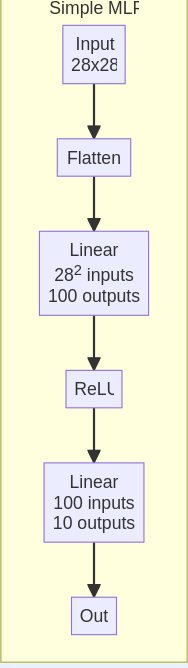

In [10]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = Linear(784, 100, True)
        self.linear2 = Linear(100, 10, True) 
        self.flatten = Flatten(1,-1) # to flatten to 28*28, remember not to flatten batch
        self.relu = ReLU()

    def forward(self, x: Tensor) -> Tensor:
        x = self.flatten(x)
        x = self.linear1(x)
        x = self.relu(x)
        y = self.linear2(x)
        return y
        


tests.test_mlp_module(SimpleMLP)
tests.test_mlp_forward(SimpleMLP)

All tests in `test_mlp_module` passed!
All tests in `test_mlp_forward` passed!


# Training NN

- learn how to deal with transforms, datasets and dataloaders
- basic structure of a training loop
- writing a validation loop

In [ ]:
MNIST_TRANSFORM = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(0.1307, 0.3081),
    ]
)



def get_mnist(trainset_size: int = 10_000, testset_size: int = 1_000) -> tuple[Subset, Subset]:
    """Returns a subset of MNIST training data."""

    # Get original datasets, which are downloaded to "./data" for future use
    mnist_trainset = datasets.MNIST( "data", train=True, download=True, transform=MNIST_TRANSFORM)
    mnist_testset = datasets.MNIST( "data", train=False, download=True, transform=MNIST_TRANSFORM)

    # # Return a subset of the original datasets
    mnist_trainset = Subset(mnist_trainset, indices=range(trainset_size))
    mnist_testset = Subset(mnist_testset, indices=range(testset_size))

    return mnist_trainset, mnist_testset


mnist_trainset, mnist_testset = get_mnist()
mnist_trainloader = DataLoader(mnist_trasys.path.insert(0, './arena_helpers')starting to iterate over `mnist_testloader`
for img_batch, label_batch in mnist_testloader:
    print(f"{img_batch.shape=}\n{label_batch.shape=}\n")
    break

# Get the first datapoint in the test set, by starting to iterate over `mnist_testset`
for img, label in mnist_testset:
    print(f"{img.shape=}\n{label=}\n")
    break

t.testing.assert_close(img, img_batch[0])
assert label == label_batch[0].item()


img_batch.shape=torch.Size([64, 1, 28, 28])
label_batch.shape=torch.Size([64])

img.shape=torch.Size([1, 28, 28])
label=7



- Here we used the `torchvision` package that has popular datasets.
- `torchvision.transforms` has access to suite of functions for preprocessing data.
- `torchvision.datasets` gets us the datasets, takes as arguments where to save data, transforms.
- `Dataloader`, wraps the datasets to work on **Batches**, also takes as an argument `shuffle` which randomizes the order after each epoch.
- we use `tqdm` which shows progress bars as seen below.

In [12]:
import time
word = "hello!"
pbar = tqdm(enumerate(word), total=len(word))
t0 = time.time()

for i, letter in pbar:
    time.sleep(1.0)
    pbar.set_postfix(i=i, letter=letter, time=f"{time.time()-t0:.3f}")
    pbar.set_description("shows the progress of the word hello")

  0%|          | 0/6 [00:00<?, ?it/s]

## Training Loop

A very simple training loop, which can run to train your model.

In [13]:
model = SimpleMLP().to(device)

batch_size = 128
epochs = 3

mnist_trainset, _ = get_mnist()
mnist_trainloader = DataLoader(mnist_trainset, batch_size=batch_size, shuffle=True)

optimizer = t.optim.Adam(model.parameters(), lr=1e-3)
loss_list = []

for epoch in range(epochs):
    pbar = tqdm(mnist_trainloader)

    for imgs, labels in pbar:
        # Move data to device, perform forward pass
        imgs, labels = imgs.to(device), labels.to(device)

        logits = model(imgs)

        # Calculate loss, perform backward pass
        loss = F.cross_entropy(logits, labels)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # Update logs & progress bar
        loss_list.append(loss.item())
        pbar.set_postfix(epoch=f"{epoch + 1}/{epochs}", loss=f"{loss:.3f}")

line(
    loss_list,
    x_max=epochs * len(mnist_trainset),
    labels={"x": "Examples seen", "y": "Cross entropy loss"},
    title="SimpleMLP training on MNIST",
    width=700,
)


  0%|          | 0/79 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Our training loop consists of:
1. evaluating the model on batch of data -> get logits and class predictions
2. calculate loss between logits & true class labels
3. backprop the loss
4. make a stop using out opimizer
5. zero out the gradients of the optimizer

## Refactoring Code

When we have a lot of input parameters. We use dataclasses to keep track of them. Here's an example of the above code but using a dataclass. Let's also a validation loop.

In [14]:
@dataclass
class SimpleMLPTrainingArgs:
    """
    Defining this class implicitly creates an __init__ method, which sets arguments as below, e.g.
    self.batch_size=64. Any of these fields can also be overridden when you create an instance, e.g.
    SimpleMLPTrainingArgs(batch_size=128).
    """

    batch_size: int = 64
    epochs: int = 3
    learning_rate: float = 1e-3


def train(args: SimpleMLPTrainingArgs) -> tuple[list[float], list[float], SimpleMLP]:
    """
    Trains & returns the model, using training parameters from the `args` object. Returns the model,
    and loss list.
    """
    model = SimpleMLP().to(device)

    mnist_trainset, mnist_testset = get_mnist()
    mnist_trainloader = DataLoader(mnist_trainset, batch_size=args.batch_size, shuffle=True)
    mnist_val_loader = DataLoader(mnist_testset, batch_size=args.batch_size, shuffle=False)
    optimizer = t.optim.Adam(model.parameters(), lr=args.learning_rate)
    loss_list = []
    accuracies = [] #for the validation loop 

    for epoch in range(args.epochs):
        pbar = tqdm(mnist_trainloader)

        for imgs, labels in pbar:
            # Move data to device, perform forward pass
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)

            # Calculate loss, perform backward pass
            loss = F.cross_entropy(logits, labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            # Update logs & progress bar
            loss_list.append(loss.item())
            pbar.set_postfix(epoch=f"{epoch + 1}/{args.epochs}", loss=f"{loss:.3f}")

        # the validation loop
        val_pbar = tqdm(mnist_val_loader)
        accuracy, total_size = 0, 0 # reinitialized after every epoch
        for val_imgs, val_labels in val_pbar:
            
            # move data to device
            val_imgs, val_labels = val_imgs.to(device), val_labels.to(device)

            # get prediction of the model on the validation images
            val_logits = model(val_imgs)
            # apply softmax for predictions to be normalized
            val_preds = F.softmax(val_logits,dim=-1)

            # get accuracy of model
            _, pred_class = t.max(val_preds, dim=-1)
            batch_accuracy = (pred_class == val_labels).int().sum()
            batch_size = val_imgs.shape[0]
            total_size += batch_size
            accuracy += batch_accuracy
        accuracies.append(accuracy.item()/total_size) 
            

    return loss_list, accuracies, model


args = SimpleMLPTrainingArgs()
loss_list, accuracies, model = train(args)

line(
    y=[loss_list, [0.1] + accuracies],  # we start by assuming a uniform accuracy of 10%
    use_secondary_yaxis=True,
    x_max=args.epochs * len(mnist_trainset),
    labels={"x": "Num examples seen", "y1": "Cross entropy loss", "y2": "Test Accuracy"},
    title="SimpleMLP training on MNIST",
    width=800,
)


  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

# Convolutions

here we'll implement `Conv2d` from sratch, using the **Kaiming initialization**. 

In [ ]:
class Conv2d(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int,
        stride: int = 1,
        padding: int = 0,
    ):
        """
        Same as torch.nn.Conv2d with bias=False.

        Name your weight field `self.weight` for compatibility with the PyTorch version.

        We assume kernel is square, with height = width = `kernel_size`.
        """
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

        # defining the bound for the kaiming initialization 1/√N_in, which is in this case includes the kernel_size since 
        self.bound = 1 / np.sqrt(in_channels * self.kernel_size * self.kernel_size)

        # initializing the weights
        weight = self.bound * (2*t.rand(self.out_channels, self.in_channels, self.kernel_size, self.kernel_size)-1)
        self.weight = nn.Parameter(weight)


        
    def forward(self, x: Tensor) -> Tensor:
        """Apply the functional conv2d, which you can import."""
        return t.nn.functional.conv2d(x, self.weight, stride=self.stride, padding=self.padding)

    def extra_repr(self) -> str:
        keys = ["in_channels", "out_channels", "kernel_size", "stride", "padding"]
        return ", ".join([f"{key}={getattr(self, key)}" for key in keys])


tests.test_conv2d_module(Conv2d)
m = Conv2d(in_channels=24, out_channels=12, kernel_size=3, stride=2, padding=1)
print(f"Manually verify that this is an informative repr: {m}")


All tests in `test_conv2d_module` passed!
Manually verify that this is an informative repr: Conv2d(in_channels=24, out_channels=12, kernel_size=3, stride=2, padding=1)


Here the bound included `in_channels * kernel_width * kernel_height`, as each output is computed over the input channels and the kernel rectangle. 

In [28]:
class MaxPool2d(nn.Module):
    def __init__(self, kernel_size: int, stride: int | None = None, padding: int = 1):
        super().__init__()
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

    def forward(self, x: Tensor) -> Tensor:
        """Call the functional version of maxpool2d."""
        return F.max_pool2d(x, kernel_size=self.kernel_size, stride=self.stride, padding=self.padding)

    def extra_repr(self) -> str:
        """Add additional information to the string representation of this class."""
        return ", ".join([f"{key}={getattr(self, key)}" for key in ["kernel_size", "stride", "padding"]])


# ResNets

Here we'll make our own version of `nn.sequential` model 

In [29]:
class Sequential(nn.Module):
    _modules: dict[str, nn.Module]

    def __init__(self, *modules: nn.Module):
        super().__init__()
        for index, mod in enumerate(modules):
            self._modules[str(index)] = mod

    def __getitem__(self, index: int) -> nn.Module:
        index %= len(self._modules)  # deal with negative indices
        return self._modules[str(index)]

    def __setitem__(self, index: int, module: nn.Module) -> None:
        index %= len(self._modules)  # deal with negative indices
        self._modules[str(index)] = module

    def forward(self, x: Tensor) -> Tensor:
        """Chain each module together, with the output from one feeding into the next one."""
        for mod in self._modules.values():
            x = mod(x)
        return x


## Implementing BatchNorm

The primary function of batchnorm is to normalize the activations of each layer within the neural network during training. It normalizes each batch of input data to have a mean of 0 and std dev of 1. This normalization helps mitigate the internal covariate shift problem, which refers to the change in the distribution of layer inputs as the network trains. This becomes a particularly big problem as we build deeper networks, because there's more opportunity for the activation distribution to change over time.

In [44]:
class BatchNorm2d(nn.Module):
    # The type hints below aren't functional, they're just for documentation
    running_mean: Float[Tensor, " num_features"]
    running_var: Float[Tensor, " num_features"]
    num_batches_tracked: Int[Tensor, ""]  # This is how we denote a scalar tensor

    def __init__(self, num_features: int, eps=1e-05, momentum=0.1):
        """
        Like nn.BatchNorm2d with track_running_stats=True and affine=True.

        Name the learnable affine parameters `weight` and `bias` in that order.
        """
        super().__init__()
        self.num_features = num_features
        self.eps = eps
        self.momentum = momentum

        # because affine is true, they will get updated
        self.weight = nn.Parameter(t.ones(num_features))
        self.bias = nn.Parameter(t.zeros(num_features))

        self.register_buffer("running_mean", t.zeros(num_features))
        self.register_buffer("running_var", t.ones(num_features))
        self.register_buffer("num_batches_tracked", t.tensor(0))

    def forward(self, x: Tensor) -> Tensor:
        """
        Normalize each channel.

        Compute the variance using `torch.var(x, unbiased=False)`
        Hint: you may also find it helpful to use the argument `keepdim`.

        x: shape (batch, channels, height, width)
        Return: shape (batch, channels, height, width)
        """

        if self.training: # notice to not waste eval time on operation for training only
            mean_x = x.mean(dim=(0,2,3), keepdim=True) # mean across batch, height and width
            var_x = x.var(dim=(0,2,3), keepdim=True, unbiased=False) # standard dev across batch height and width
            self.num_batches_tracked += 1

            # exponential moving average
            self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * mean_x.squeeze()
            self.running_var = (1 - self.momentum) * self.running_var + self.momentum * var_x.squeeze()
            
            # Use this data's mean & variance to normalize, then use it to update the buffers
            normalized_x = (x - mean_x)/t.sqrt(var_x + self.eps)
        else:
            # Use the buffer mean & variance to normalize
            normalized_x = (x - self.running_mean.reshape((self.num_features, 1, 1)))/t.sqrt(self.running_var.reshape((self.num_features,1,1)) + self.eps)
        
        # element wise operation
        y = normalized_x * self.weight.reshape((self.num_features, 1,1)) + self.bias.reshape((self.num_features,1,1)) 
        
        return y
    def extra_repr(self) -> str:
        raise f"Using Momentum={self.momentum}, epsilon={self.eps}, number of features are {self.num_features}"

tests.test_batchnorm2d_module(BatchNorm2d)
tests.test_batchnorm2d_forward(BatchNorm2d)
tests.test_batchnorm2d_running_mean(BatchNorm2d)


All tests in `test_batchnorm2d_module` passed!
All tests in `test_batchnorm2d_forward` passed!
All tests in `test_batchnorm2d_running_mean` passed!


## Average Pooling

This is a very straightforward implementation of average pool. Let's use einops for flexing reasons.

In [45]:
class AveragePool(nn.Module):
    def forward(self, x: Tensor) -> Tensor:
        """
        x: shape (batch, channels, height, width)
        Return: shape (batch, channels)
        """
        y = einops.reduce(x, "b c h w -> b c","mean")
        return y


tests.test_averagepool(AveragePool)


All tests in `test_averagepool` passed!


## Implementing ResidualBlock

In [50]:
class ResidualBlock(nn.Module):
    def __init__(self, in_feats: int, out_feats: int, first_stride=1):
        """
        A single residual block with optional downsampling.

        For compatibility with the pretrained model, declare the left side branch first using a
        `Sequential`.

        If first_stride is > 1, this means the optional (conv + bn) should be present on the right
        branch. Declare it second using another `Sequential`.
        """
        super().__init__()
        is_shape_preserving = (first_stride == 1) and (in_feats == out_feats)  # determines if right branch is identity
        
        self.in_feats = in_feats
        self.out_feats = out_feats
        self.first_stride = first_stride

        self.relu = ReLU() # instantiating

        self.left_branch = Sequential(
            Conv2d(self.in_feats, self.out_feats, 3, self.first_stride, 1),
            BatchNorm2d(self.out_feats),
            ReLU(),
            Conv2d(self.out_feats, self.out_feats, 3, 1, 1),
            BatchNorm2d(self.out_feats)
        )

        if not is_shape_preserving:
            self.right_branch = Sequential(
                Conv2d(self.in_feats, self.out_feats, 1, self.first_stride, 0), 
                BatchNorm2d(self.out_feats)
            )
        else:
            self.right_branch = nn.Identity() # returns input as is

    def forward(self, x: Tensor) -> Tensor:
        """
        Compute the forward pass. If no downsampling block is present, the addition should just add
        the left branch's output to the input.

        x: shape (batch, in_feats, height, width)

        Return: shape (batch, out_feats, height / stride, width / stride)
        """
        x = self.right_branch(x) + self.left_branch(x)
        x = self.relu(x)
        return x


tests.test_residual_block(ResidualBlock)


Passed all tests when first_stride=1
Passed all tests when first_stride>1
All tests in `test_residual_block` passed!


## Implementing `BlockGroup`

According to the diagram below there should be `n_blocks` total blocks in the group. The first block has possibility of a right branch.

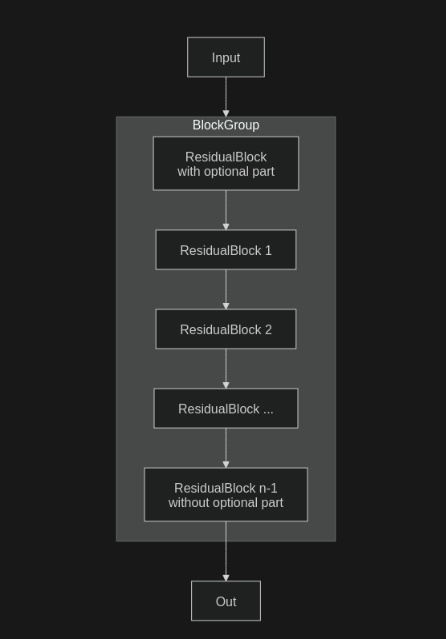




In [57]:
class BlockGroup(nn.Module):
    def __init__(self, n_blocks: int, in_feats: int, out_feats: int, first_stride=1):
        """
        An n_blocks-long sequence of ResidualBlock where only the first block uses the provided
        stride.
        """
        super().__init__()

        # list of blocks instantiations
        self.blocks = []

        # first block is different from rest
        self.first_block = ResidualBlock(in_feats, out_feats, first_stride)
        self.blocks.append(self.first_block)

        for i in range(n_blocks-1):
            layer = ResidualBlock(out_feats, out_feats)
            self.blocks.append(layer)
        
        # the whole res_block
        self.res_block = Sequential(*self.blocks)
        
    def forward(self, x: Tensor) -> Tensor:
        """
        Compute the forward pass.

        x: shape (batch, in_feats, height, width)

        Return: shape (batch, out_feats, height / first_stride, width / first_stride)
        """
        return self.res_block(x)


tests.test_block_group(BlockGroup)


Passed all tests when first_stride=1
Passed all tests when first_stride>1
Passed all tests when n_blocks>2
All tests in `test_block_group` passed!


## Assembling `ResNet34`

Now let's assemble `ResNet34`! With the below architecture.

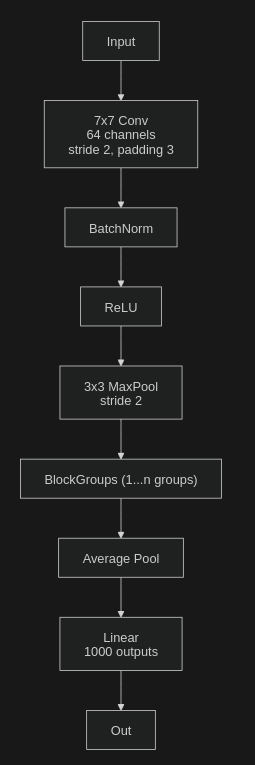

In [65]:
class ResNet34(nn.Module):
    def __init__(
        self,
        n_blocks_per_group=[3, 4, 6, 3],
        out_features_per_group=[64, 128, 256, 512],
        first_strides_per_group=[1, 2, 2, 2],
        n_classes=1000,
    ):
        super().__init__()
        out_feats0 = 64
        self.n_blocks_per_group = n_blocks_per_group
        self.out_features_per_group = out_features_per_group
        self.first_strides_per_group = first_strides_per_group
        self.n_classes = n_classes

        self.n_groups = len(self.n_blocks_per_group)

        # initial layers
        self.conv2d = Conv2d(3, 64, 7, 1, 3) # 3 channels for images
        self.batch_norm = BatchNorm2d(64)
        self.relu = ReLU()
        self.max_pool = nn.MaxPool2d(3,2)

        # list of sequential groups
        self.groups = []

        self.in_feats = out_feats0

        for group_i in range(self.n_groups): # looping over the n groups
            self.groups.append(BlockGroup(self.n_blocks_per_group[group_i], self.in_feats, out_features_per_group[group_i], first_strides_per_group[group_i]))
            # the in features of group_n is the out features of group_n-1
            self.in_feats = out_features_per_group[group_i]

        self.core_block = nn.Sequential(
            *self.groups
        )

        self.avg_pool = AveragePool()
        self.flatten = Flatten()
        self.linear = Linear(self.out_features_per_group[-1],self.n_classes)

            
        

    def forward(self, x: Tensor) -> Tensor:
        """
        x: shape (batch, channels, height, width)
        Return: shape (batch, n_classes)
        """
        x = self.conv2d(x)
        x = self.batch_norm(x)
        x = self.relu(x)
        x = self.max_pool(x)
        x = self.core_block(x)
        x = self.avg_pool(x)
        x = self.flatten(x)
        x = self.linear(x)
        return x



my_resnet = ResNet34()

# (1) Test via helper function `print_param_count`
target_resnet = models.resnet34()  # without supplying a `weights` argument, we just initialize with random weights
utils.print_param_count(my_resnet, target_resnet)

# (2) Test via `torchinfo.summary`
print("My model:", torchinfo.summary(my_resnet, input_size=(1, 3, 64, 64)), sep="\n")
print(
    "\nReference model:",
    torchinfo.summary(target_resnet, input_size=(1, 3, 64, 64), depth=2),
    sep="\n",
)


Model 1, total params = 21797672
Model 2, total params = 21797672
All parameter shapes match, and are in the same order!


,name_1,shape_1,num_params_1,num_params_2,shape_2,name_2
0,conv2d.weight,"(64, 3, 7, 7)",9408,9408,"(64, 3, 7, 7)",conv1.weight
1,batch_norm.weight,"(64,)",64,64,"(64,)",bn1.weight
2,batch_norm.bias,"(64,)",64,64,"(64,)",bn1.bias
3,core_block.0.first_block.left_branch.0.weight,"(64, 64, 3, 3)",36864,36864,"(64, 64, 3, 3)",layer1.0.conv1.weight
4,core_block.0.first_block.left_branch.1.weight,"(64,)",64,64,"(64,)",layer1.0.bn1.weight
5,core_block.0.first_block.left_branch.1.bias,"(64,)",64,64,"(64,)",layer1.0.bn1.bias
6,core_block.0.first_block.left_branch.3.weight,"(64, 64, 3, 3)",36864,36864,"(64, 64, 3, 3)",layer1.0.conv2.weight
7,core_block.0.first_block.left_branch.4.weight,"(64,)",64,64,"(64,)",layer1.0.bn2.weight
8,core_block.0.first_block.left_branch.4.bias,"(64,)",64,64,"(64,)",layer1.0.bn2.bias
9,core_block.0.res_block.1.left_branch.0.weight,"(64, 64, 3, 3)",36864,36864,"(64, 64, 3, 3)",layer1.1.conv1.weight


My model:
Layer (type:depth-idx)                             Output Shape              Param #
ResNet34                                           [1, 1000]                 --
├─Conv2d: 1-1                                      [1, 64, 64, 64]           9,408
├─BatchNorm2d: 1-2                                 [1, 64, 64, 64]           128
├─ReLU: 1-3                                        [1, 64, 64, 64]           --
├─MaxPool2d: 1-4                                   [1, 64, 31, 31]           --
├─Sequential: 1-5                                  [1, 512, 4, 4]            --
│    └─BlockGroup: 2-1                             [1, 64, 31, 31]           --
│    │    └─Sequential: 3-1                        [1, 64, 31, 31]           221,952
│    └─BlockGroup: 2-2                             [1, 128, 16, 16]          --
│    │    └─Sequential: 3-2                        [1, 128, 16, 16]          1,116,416
│    └─BlockGroup: 2-3                             [1, 256, 8, 8]            --
│    │   

In [62]:
resnet = models.resnet34()
print(torchinfo.summary(resnet, input_size=(1, 3, 64, 64)))
print(torchinfo.summary(my_resnet, input_size=(1, 3, 64, 64)))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 32, 32]           9,408
├─BatchNorm2d: 1-2                       [1, 64, 32, 32]           128
├─ReLU: 1-3                              [1, 64, 32, 32]           --
├─MaxPool2d: 1-4                         [1, 64, 16, 16]           --
├─Sequential: 1-5                        [1, 64, 16, 16]           --
│    └─BasicBlock: 2-1                   [1, 64, 16, 16]           --
│    │    └─Conv2d: 3-1                  [1, 64, 16, 16]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 16, 16]           128
│    │    └─ReLU: 3-3                    [1, 64, 16, 16]           --
│    │    └─Conv2d: 3-4                  [1, 64, 16, 16]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 16, 16]           128
│    │    └─ReLU: 3-6                    [1, 64, 16, 16]           --
│

NameError: name 'my_resnet' is not defined